In [1]:
# Importation des bibliothèques nécessaires
import cv2
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr
from PIL import Image

# Pour l’évaluation avancée (matrice de confusion, rapport)
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# Chargement du dataset MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Vérification des dimensions
print("x_train shape :", x_train.shape)
print("y_train shape :", y_train.shape)
print("x_test shape  :", x_test.shape)
print("y_test shape  :", y_test.shape)


x_train shape : (60000, 28, 28)
y_train shape : (60000,)
x_test shape  : (10000, 28, 28)
y_test shape  : (10000,)


In [3]:
# Normalisation des images (valeurs entre 0 et 1)
x_train = x_train / 255.0
x_test = x_test / 255.0


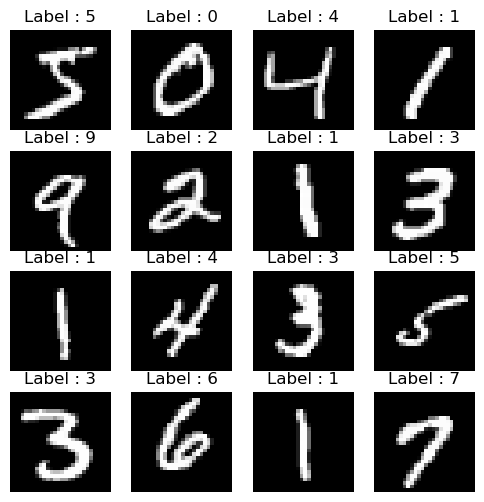

In [4]:
plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label : {y_train[i]}")
    plt.axis('off')

plt.show()


In [5]:
# Création du modèle MLP
model_mlp = tf.keras.models.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entraînement

history = model_mlp.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

# Sauvegarde
model_mlp.save("model_mlp.keras")


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8961 - loss: 0.3775 - val_accuracy: 0.9582 - val_loss: 0.1720
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9501 - loss: 0.1751 - val_accuracy: 0.9625 - val_loss: 0.1344
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9634 - loss: 0.1267 - val_accuracy: 0.9702 - val_loss: 0.1028
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9720 - loss: 0.0978 - val_accuracy: 0.9737 - val_loss: 0.0927
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9770 - loss: 0.0798 - val_accuracy: 0.9768 - val_loss: 0.0889
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9812 - loss: 0.0668 - val_accuracy: 0.9782 - val_loss: 0.0780
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9846 - loss: 0.0548 - val_accuracy: 0.9778 - val_loss: 0.0789
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9874 - loss: 0.0468 - val_accuracy: 0.

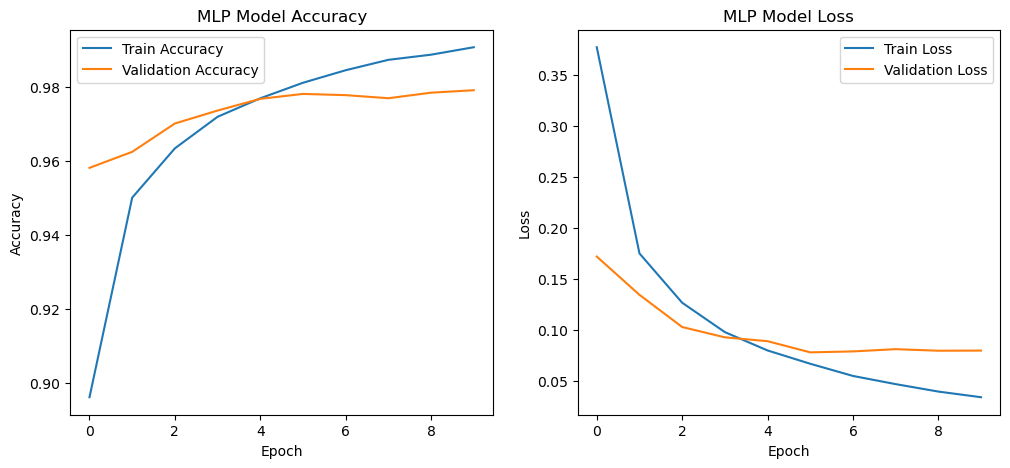

In [6]:
plt.figure(figsize=(12,5))

# ----- Accuracy -----
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MLP Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# ----- Loss -----
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Image : digit1.png
→ Chiffre prédit : 3


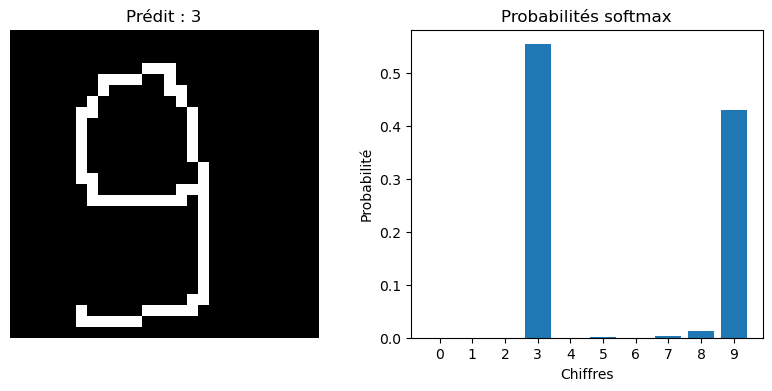

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Image : digit10.png
→ Chiffre prédit : 7


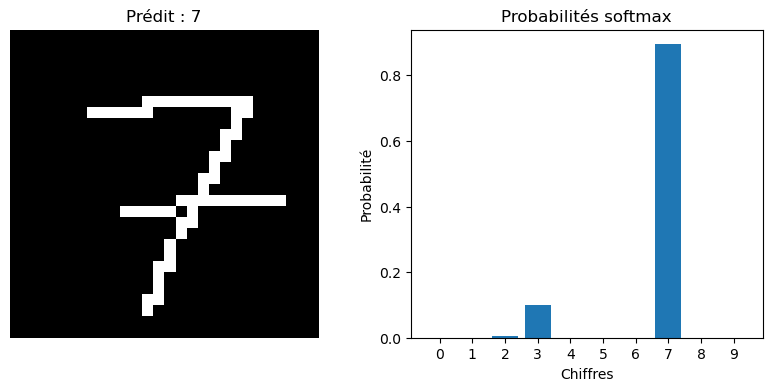

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Image : digit11.png
→ Chiffre prédit : 9


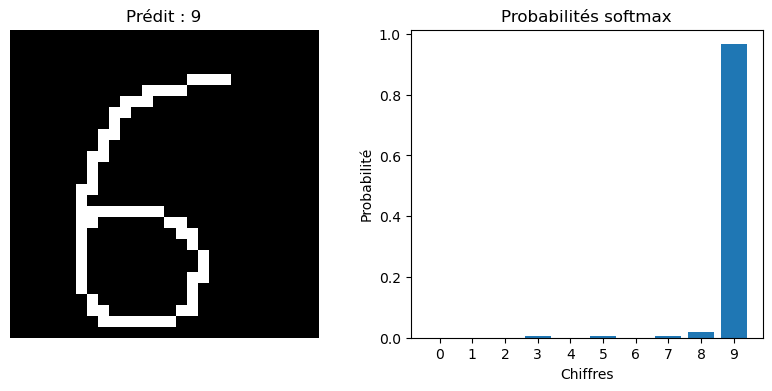

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Image : digit12.png
→ Chiffre prédit : 3


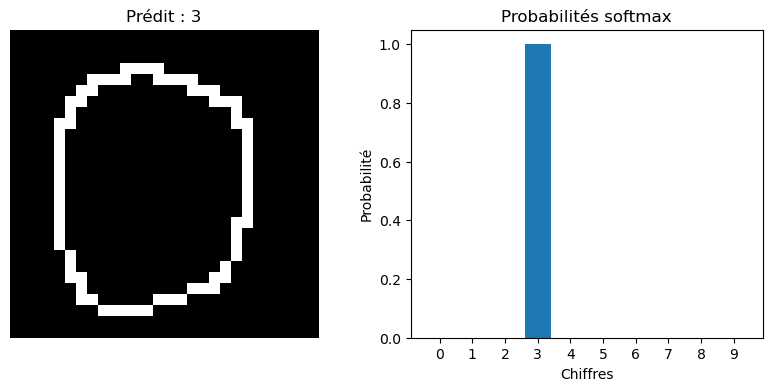

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Image : digit2.png
→ Chiffre prédit : 7


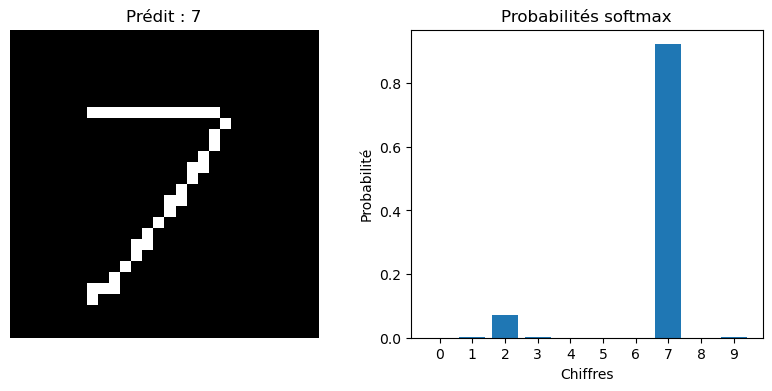

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

Image : digit3.png
→ Chiffre prédit : 8


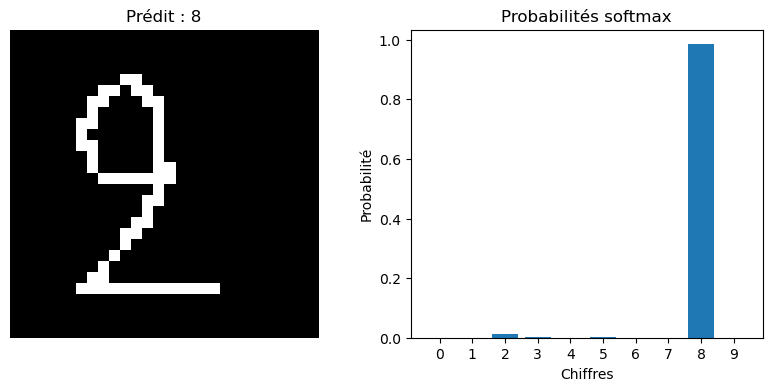

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Image : digit4.png
→ Chiffre prédit : 6


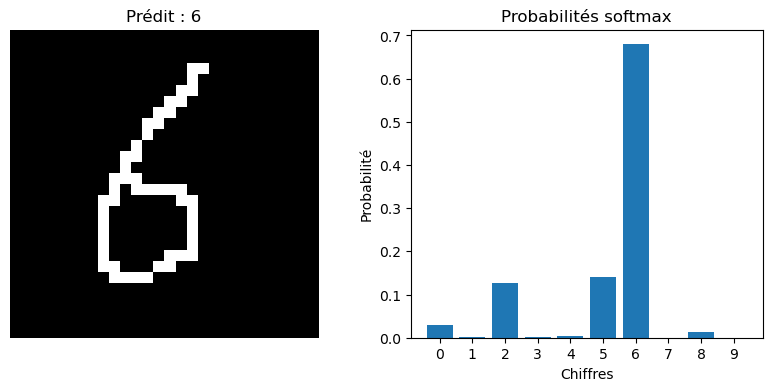

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Image : digit5.png
→ Chiffre prédit : 3


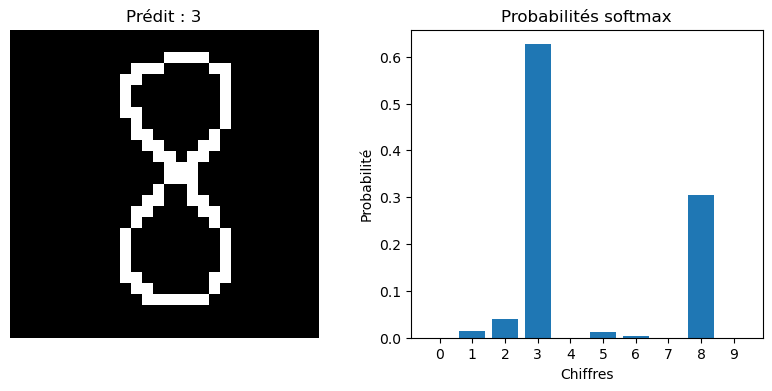

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Image : digit6.png
→ Chiffre prédit : 5


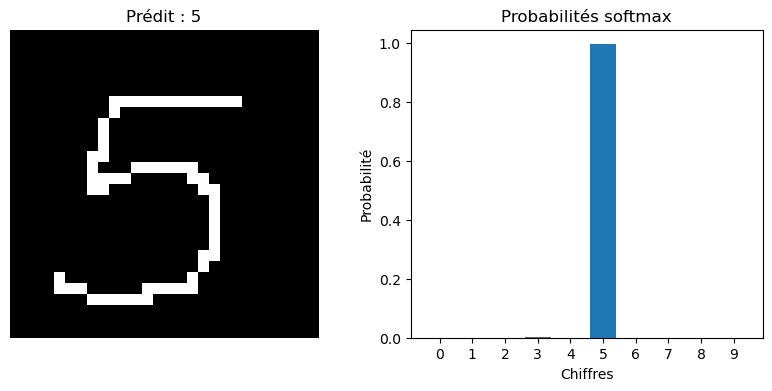

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

Image : digit7.png
→ Chiffre prédit : 1


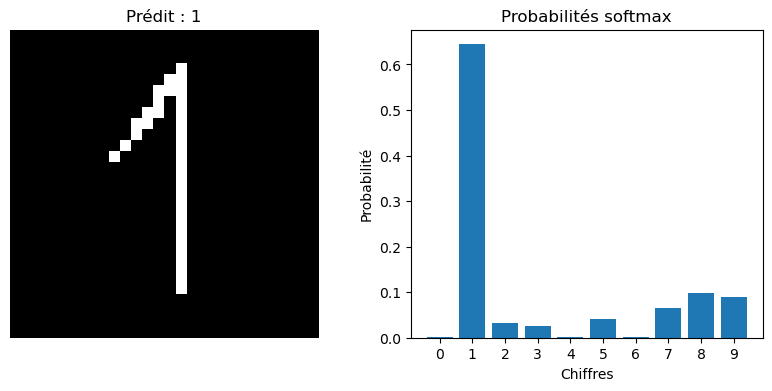

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Image : digit8.png
→ Chiffre prédit : 3


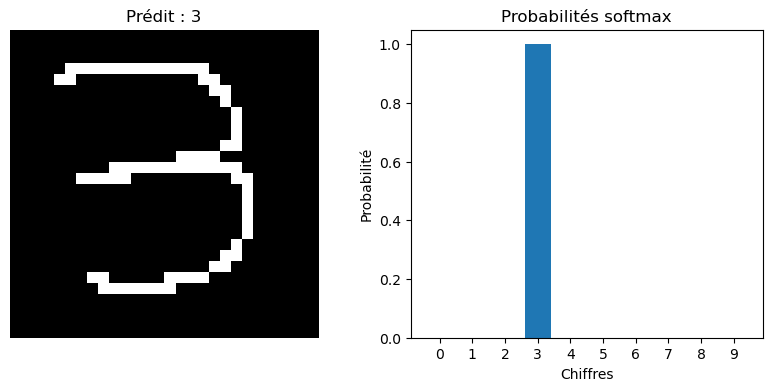

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Image : digit9.png
→ Chiffre prédit : 5


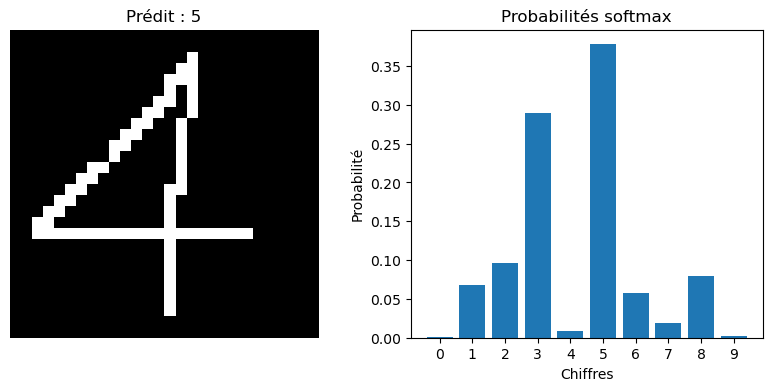

In [7]:
#test du modele MLP

model_mlp = tf.keras.models.load_model("model_mlp.keras")

# Fonction de prétraitement d'une image externe
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28, 28))
    img = cv2.bitwise_not(img)
    img = img / 255.0
    img = img.reshape(1, 28, 28, 1)
    return img


for filename in os.listdir("images"):
    if filename.endswith(".png") or filename.endswith(".jpg"):
        path = os.path.join("images", filename)

        img = preprocess_image(path)
        prediction = model_mlp.predict(img)
        probabilities = prediction[0]

        digit = np.argmax(probabilities)

        print(f"\nImage : {filename}")
        print(f"→ Chiffre prédit : {digit}")

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.imshow(img[0, :, :, 0], cmap="gray")
        plt.title(f"Prédit : {digit}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.bar(range(10), probabilities)
        plt.xticks(range(10))
        plt.xlabel("Chiffres")
        plt.ylabel("Probabilité")
        plt.title("Probabilités softmax")

        plt.show()


In [8]:
# pretraitement des images pour CNN (ajout dimension canal)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# Création du modèle CNN
cnn_model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compilation
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entraînement avec validation
history_cnn=cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1
)

# Évaluation sur test
test_loss, test_accuracy = cnn_model.evaluate(x_test_cnn, y_test)
print("Test accuracy :", test_accuracy)

# Sauvegarde
cnn_model.save("mnist_cnn.keras")


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9589 - loss: 0.1394 - val_accuracy: 0.9820 - val_loss: 0.0626
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9850 - loss: 0.0472 - val_accuracy: 0.9898 - val_loss: 0.0345
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9902 - loss: 0.0315 - val_accuracy: 0.9905 - val_loss: 0.0327
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9928 - loss: 0.0221 - val_accuracy: 0.9905 - val_loss: 0.0353
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9948 - loss: 0.0165 - val_accuracy: 0.9907 - val_loss: 0.0307
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9956 - loss: 0.0130 - val_accuracy: 0.9895 - val_loss: 0.0442
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9968 - loss: 0.0092 - val_accuracy: 0.9913 - val_loss: 0.0346
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9971 - loss: 0

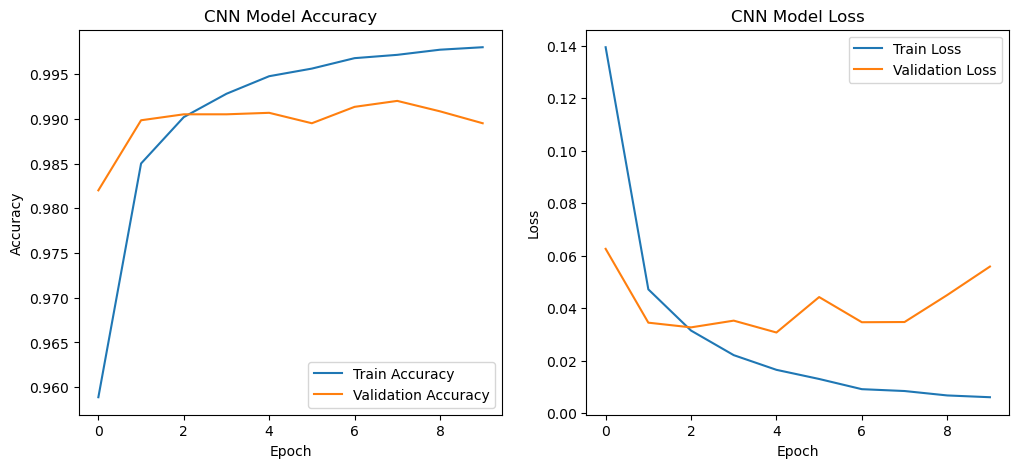

In [9]:
plt.figure(figsize=(12,5))

# ----- Accuracy -----
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# ----- Loss -----
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [10]:
# Prédictions
# y_pred = cnn_model.predict(x_test_cnn)
# y_pred_classes = np.argmax(y_pred, axis=1)

# # Matrice de confusion
# cm = confusion_matrix(y_test, y_pred_classes)
# print("Matrice de confusion :\n", cm)

# # Rapport de classification
# print("\nClassification Report :\n")
# print(classification_report(y_test, y_pred_classes))


In [ ]:
#test du modele CNN

model = tf.keras.models.load_model("mnist_cnn.keras")

# Fonction de prétraitement d'une image externe
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28, 28))
    img = cv2.bitwise_not(img)
    img = img / 255.0
    img = img.reshape(1, 28, 28, 1)
    return img

for filename in os.listdir("images"):
    if filename.endswith(".png") or filename.endswith(".jpg"):
        path = os.path.join("images", filename)

        img = preprocess_image(path)
        prediction = model.predict(img)
        probabilities = prediction[0]

        digit = np.argmax(probabilities)

        print(f"\nImage : {filename}")
        print(f"→ Chiffre prédit : {digit}")

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.imshow(img[0, :, :, 0], cmap="gray")
        plt.title(f"Prédit : {digit}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.bar(range(10), probabilities)
        plt.xticks(range(10))
        plt.xlabel("Chiffres")
        plt.ylabel("Probabilité")
        plt.title("Probabilités softmax")

        plt.show()


In [12]:
model = tf.keras.models.load_model("mnist_cnn.keras")

def predict(data):
    image = data["composite"]

    if isinstance(image, np.ndarray):
        image = image[:, :, 0]

    from PIL import Image
    image = Image.fromarray(image).resize((28, 28))

    image = np.array(image) / 255.0
    image = 1 - image  # invert for MNIST

    image = image.reshape(1, 28, 28)

    prediction = model.predict(image)
    return int(np.argmax(prediction))


demo = gr.Interface(
    fn=predict,
    inputs=gr.Sketchpad(width=280, height=280),
    outputs="label"
)

demo.launch(inline=True)


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy MLP : 0.9779
Accuracy CNN : 0.9900



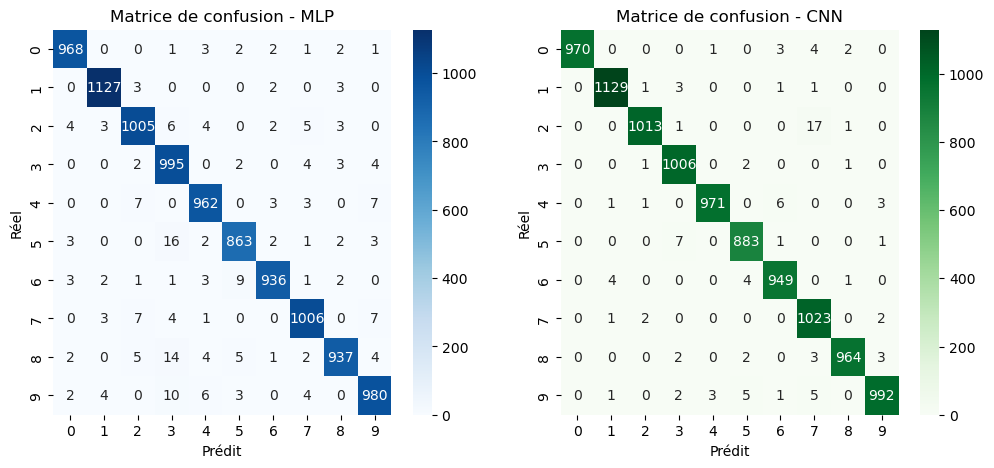

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Charger les modèles
mlp_model = tf.keras.models.load_model("handwritten_digits.keras")
cnn_model = tf.keras.models.load_model("mnist_cnn.keras")

# Prédictions sur le test set
y_pred_mlp = np.argmax(mlp_model.predict(x_test), axis=1)
y_pred_cnn = np.argmax(cnn_model.predict(x_test.reshape(-1,28,28,1)), axis=1)

# Accuracy
acc_mlp = accuracy_score(y_test, y_pred_mlp)
acc_cnn = accuracy_score(y_test, y_pred_cnn)

print(f"Accuracy MLP : {acc_mlp:.4f}")
print(f"Accuracy CNN : {acc_cnn:.4f}\n")

# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt="d", ax=axes[0], cmap="Blues")
axes[0].set_title("Matrice de confusion - MLP")
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt="d", ax=axes[1], cmap="Greens")
axes[1].set_title("Matrice de confusion - CNN")
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")

plt.show()


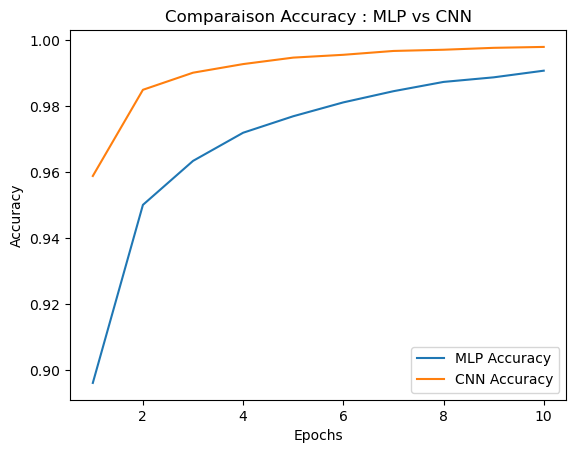

In [14]:
mlp_acc = history.history['accuracy']
cnn_acc = history_cnn.history['accuracy']

epochs = range(1, len(mlp_acc) + 1)

plt.figure()
plt.plot(epochs, mlp_acc, label='MLP Accuracy')
plt.plot(epochs, cnn_acc, label='CNN Accuracy')

plt.title("Comparaison Accuracy : MLP vs CNN")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

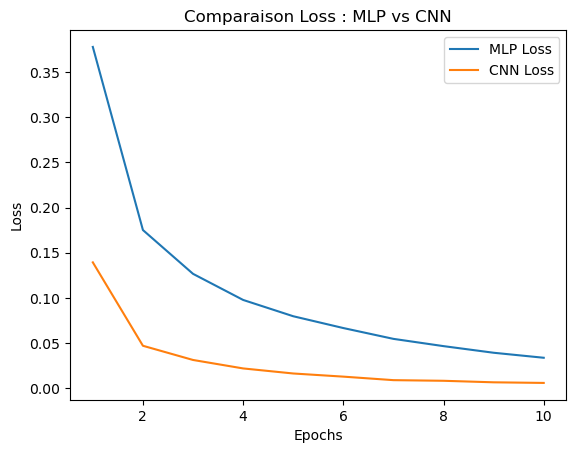

In [15]:
mlp_loss = history.history['loss']
cnn_loss = history_cnn.history['loss']

epochs = range(1, len(mlp_loss) + 1)

plt.figure()
plt.plot(epochs, mlp_loss, label='MLP Loss')
plt.plot(epochs, cnn_loss, label='CNN Loss')

plt.title("Comparaison Loss : MLP vs CNN")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

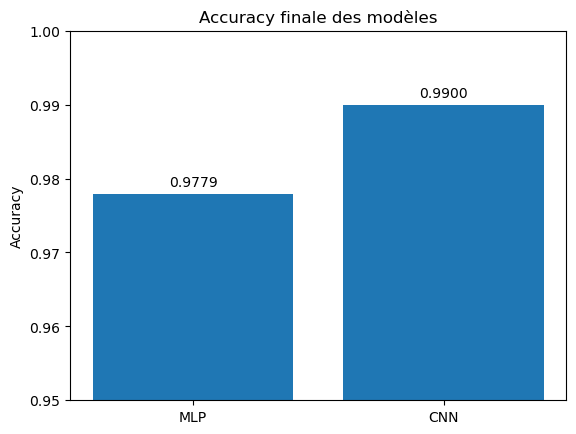

In [16]:
import matplotlib.pyplot as plt

models = ['MLP', 'CNN']
accuracy = [acc_mlp, acc_cnn]

plt.figure()
plt.bar(models, accuracy)

plt.title("Accuracy finale des modèles")
plt.ylabel("Accuracy")

# zoom sur la zone où se trouvent les valeurs
plt.ylim(0.95, 1.0)

# afficher les valeurs exactes au-dessus des barres
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')

plt.show()

In [35]:
# Import des bibliothèques nécessaires
from sklearn.metrics import f1_score
import numpy as np


# Charger les modèles sauvegardés
model_mlp = tf.keras.models.load_model("model_mlp.keras")
model_cnn = tf.keras.models.load_model("mnist_cnn.keras")

# Préparer les données de test
# MLP accepte l'entrée (28,28) directement grâce à la couche Flatten
x_test_mlp = x_test  # shape (10000, 28, 28)

# CNN nécessite une dimension canal (28,28,1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# Prédictions MLP
y_pred_mlp_prob = model_mlp.predict(x_test_mlp)
y_pred_mlp = np.argmax(y_pred_mlp_prob, axis=1)

# Prédictions CNN
y_pred_cnn_prob = model_cnn.predict(x_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)

# Calcul des F1-scores
f1_mlp_macro = f1_score(y_test, y_pred_mlp, average='macro')
f1_mlp_micro = f1_score(y_test, y_pred_mlp, average='micro')
f1_cnn_macro = f1_score(y_test, y_pred_cnn, average='macro')
f1_cnn_micro = f1_score(y_test, y_pred_cnn, average='micro')

# Affichage des résultats
print("=== F1-Score (macro) ===")
print(f"MLP : {f1_mlp_macro:.4f}")
print(f"CNN : {f1_cnn_macro:.4f}\n")

print("=== F1-Score (micro) ===")
print(f"MLP : {f1_mlp_micro:.4f}")
print(f"CNN : {f1_cnn_micro:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== F1-Score (macro) ===
MLP : 0.9766
CNN : 0.9900

=== F1-Score (micro) ===
MLP : 0.9768
CNN : 0.9900


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== F1-Score (macro) ===
MLP : 0.9766
CNN : 0.9900

=== F1-Score (micro) ===
MLP : 0.9768
CNN : 0.9900


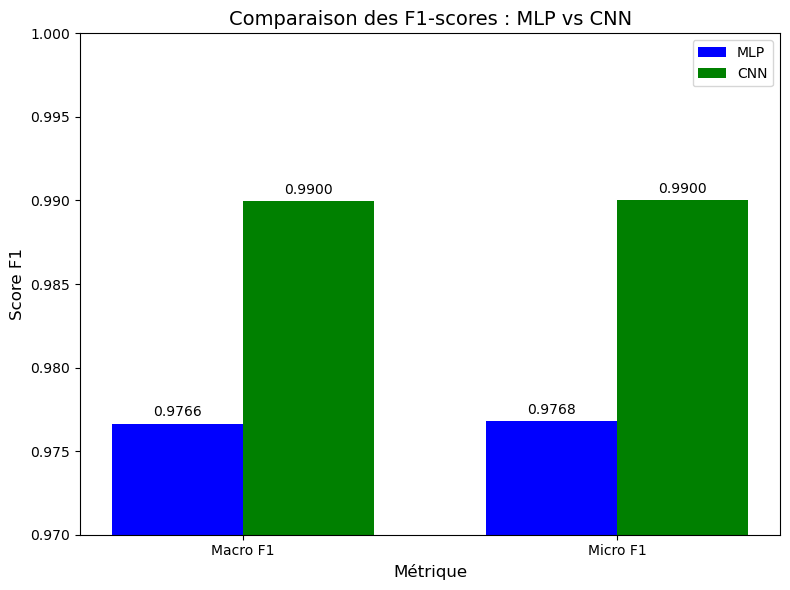

In [37]:
# Import des bibliothèques nécessaires
from sklearn.metrics import f1_score
import numpy as np

# ------------------------------
# 1. Charger les modèles
# ------------------------------
model_mlp = tf.keras.models.load_model("model_mlp.keras")
model_cnn = tf.keras.models.load_model("mnist_cnn.keras")

# ------------------------------
# 2. Préparer les données de test
# ------------------------------
# Les données x_test et y_test doivent être disponibles (chargées précédemment)
# Si ce n'est pas le cas, les charger depuis MNIST
from tensorflow.keras.datasets import mnist
(_, _), (x_test, y_test) = mnist.load_data()
x_test = x_test / 255.0  # normalisation

# MLP accepte l'entrée (28,28) grâce à la couche Flatten
x_test_mlp = x_test

# CNN nécessite une dimension canal (28,28,1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# ------------------------------
# 3. Prédictions
# ------------------------------
y_pred_mlp = np.argmax(model_mlp.predict(x_test_mlp), axis=1)
y_pred_cnn = np.argmax(model_cnn.predict(x_test_cnn), axis=1)

# ------------------------------
# 4. Calcul des F1-scores
# ------------------------------
f1_mlp_macro = f1_score(y_test, y_pred_mlp, average='macro')
f1_mlp_micro = f1_score(y_test, y_pred_mlp, average='micro')
f1_cnn_macro = f1_score(y_test, y_pred_cnn, average='macro')
f1_cnn_micro = f1_score(y_test, y_pred_cnn, average='micro')

# ------------------------------
# 5. Affichage des valeurs
# ------------------------------
print("=== F1-Score (macro) ===")
print(f"MLP : {f1_mlp_macro:.4f}")
print(f"CNN : {f1_cnn_macro:.4f}\n")
print("=== F1-Score (micro) ===")
print(f"MLP : {f1_mlp_micro:.4f}")
print(f"CNN : {f1_cnn_micro:.4f}")

# ------------------------------
# 6. Graphique de comparaison
# ------------------------------
labels = ['Macro F1', 'Micro F1']
mlp_scores = [f1_mlp_macro, f1_mlp_micro]
cnn_scores = [f1_cnn_macro, f1_cnn_micro]

x = np.arange(len(labels))          # position des groupes
width = 0.35                         # largeur des barres

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, mlp_scores, width, label='MLP', color='blue')
bars2 = ax.bar(x + width/2, cnn_scores, width, label='CNN', color='green')

# Ajouter les valeurs numériques sur les barres
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Métrique', fontsize=12)
ax.set_ylabel('Score F1', fontsize=12)
ax.set_title('Comparaison des F1‑scores : MLP vs CNN', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0.97, 1.0)   # zoom pour mieux visualiser les écarts
plt.tight_layout()
plt.show()